# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Load the dataset from this URL:
  https://github.com/Stan-Pugsley/is_4487_base/blob/d764a81fe649c397a1f5b35f1e1ceda48b5178d1/DataSets/hotels.csv?raw=true
- Display the first few rows to confirm it loaded correctly.


In [10]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from the given URL
url = "https://github.com/Stan-Pugsley/is_4487_base/blob/main/DataSets/hotels.csv?raw=true"
hotels = pd.read_csv(url)

# Display the first few rows to confirm it loaded correctly
hotels.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### In your markdown:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Stakeholders: hotel managers, marketing/sales, revenue teams.

2. Goals: improve occupancy, decrease cancellations, optimize pricing/marketing.

3. Business Problem: What factors most strongly influence booking cancellations, and how can hotels use this information to reduce cancellation rates and improve occupancy forecasting?




## 3. Explore Data Structure and Quality

Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks
- Flag any issues you notice (e.g., missing values, formatting problems)

In [11]:
# Summary of the dataset
print("----- INFO -----")
print(hotels.info())
print("\n----- DESCRIBE -----")
print(hotels.describe(include='all'))

# Count missing values
print("\n----- MISSING VALUES -----")
print(hotels.isna().sum())

# Count duplicate rows
print("\n----- DUPLICATES -----")
print(hotels.duplicated().sum())


----- INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

### In your markdown:
1. What structural issues or problems did you find?
2. What actions would you recommend to clean or prepare this dataset for use?

### ✍️ Your Response: 🔧
1. The dataset has some missing values in columns like children, country, and agent. I also noticed that there are duplicate rows, and the arrival_date_month column is stored as text instead of a numeric format.

2. To prepare the dataset, I would recommend handling the missing values either by filling them in or removing the affected rows, dropping the duplicate records, and converting categorical variables like arrival_date_month into a numeric or consistent format for easier analysis.



## 4. Univariate Analysis

Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

Cancellation Value Counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


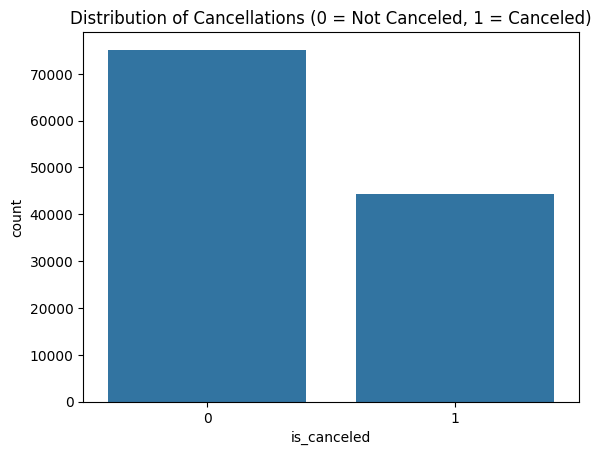


Lead Time Summary:
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


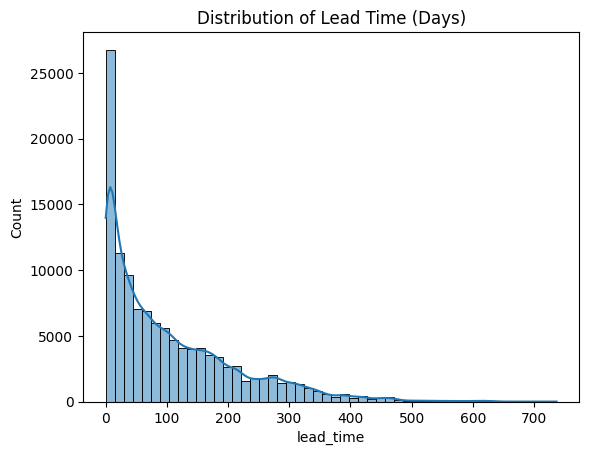


ADR Summary:
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


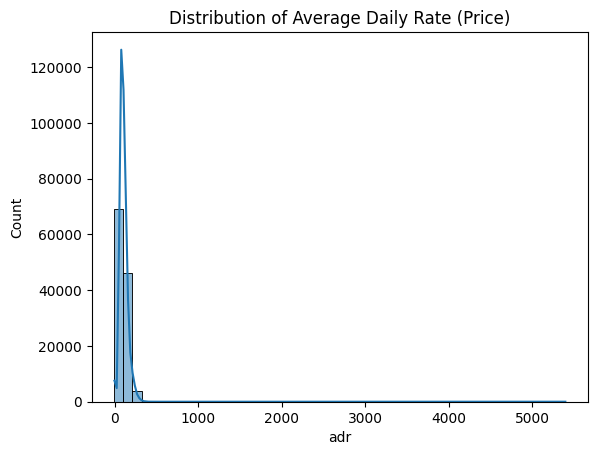

In [12]:
# Univariate Analysis

# 1. Cancellations
print("Cancellation Value Counts:")
print(hotels['is_canceled'].value_counts())
sns.countplot(x='is_canceled', data=hotels)
plt.title("Distribution of Cancellations (0 = Not Canceled, 1 = Canceled)")
plt.show()

# 2. Lead time
print("\nLead Time Summary:")
print(hotels['lead_time'].describe())
sns.histplot(hotels['lead_time'], bins=50, kde=True)
plt.title("Distribution of Lead Time (Days)")
plt.show()

# 3. Average Daily Rate (price)
print("\nADR Summary:")
print(hotels['adr'].describe())
sns.histplot(hotels['adr'], bins=50, kde=True)
plt.title("Distribution of Average Daily Rate (Price)")
plt.show()



### In your markdown:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:** Cancellations (is_canceled):
Most bookings were not canceled, but there is still a large share (around one-third) that were canceled. This highlights cancellations as a major business issue for hotels.
- **Variable 2 – Summary and insights:** Lead Time (lead_time):
Lead times are highly skewed, with many guests booking far in advance while some book last-minute. This shows the need for flexible planning and demand forecasting.
- **Variable 3 – Summary and insights:** Average Daily Rate (adr):
The majority of nightly rates are clustered around average mid-range prices, but there are extreme outliers with unusually high values. These may represent data errors or luxury cases.

## 5. Bivariate Analysis

Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

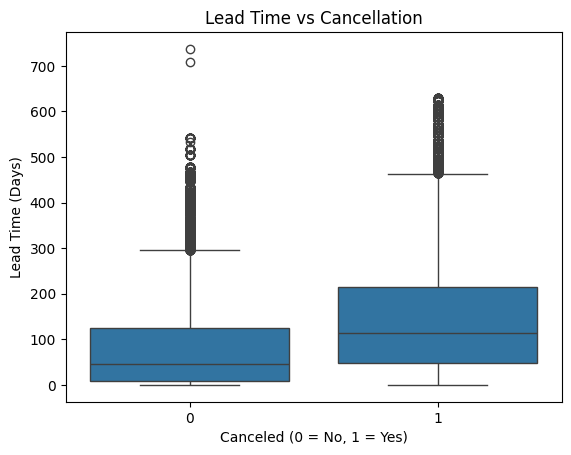

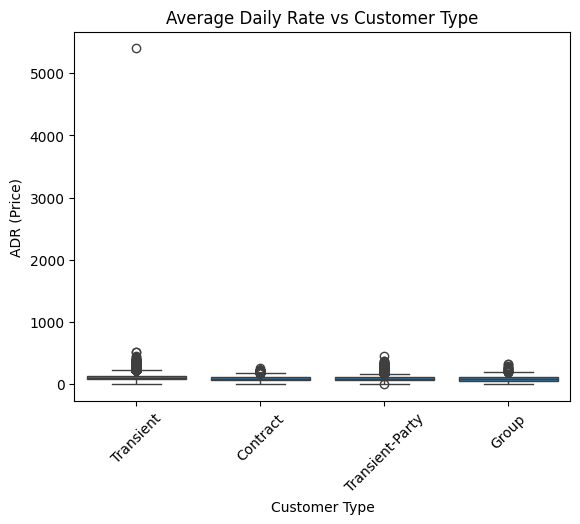

In [13]:
# Bivariate Analysis

# 1. Lead time vs Cancellations
sns.boxplot(x='is_canceled', y='lead_time', data=hotels)
plt.title("Lead Time vs Cancellation")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (Days)")
plt.show()

# 2. ADR (price) vs Customer Type
sns.boxplot(x='customer_type', y='adr', data=hotels)
plt.title("Average Daily Rate vs Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("ADR (Price)")
plt.xticks(rotation=45)
plt.show()


### In your markdown:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:** Lead time vs cancellations: I analyzed how booking lead time relates to cancellations. The results showed that bookings made far in advance are more likely to be canceled compared to last-minute reservations. This suggests that hotels may need to apply stricter cancellation policies or require deposits for long lead-time bookings.
- **Relationship 2:** ADR vs customer type: I explored how average daily rate (ADR) varies by customer type. The analysis showed that transient customers tend to pay higher rates, while contract and group customers usually pay lower rates. This highlights the importance of segment-based pricing strategies in hotel revenue management.


## 6. Problem Complexity and Analytics Framing

Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### In your markdown:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. My selected insight is that bookings with longer lead times are more likely to be canceled.
2. This involves variability and volume complexity, since cancellation likelihood changes depending on booking behavior and patterns over time.
3. Predictive analytics would help because hotels could build models to forecast which bookings are most at risk of cancellation and adjust policies or pricing strategies accordingly.



## 7. Final Takeaways and Recommendations

Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

- Identify your top 2–3 insights or patterns
- Connect each to a stakeholder need or business goal
- Make one recommendation based on the analysis

### In your markdown:
1. What patterns or trends stood out?
2. How do they connect to stakeholder goals?
3. What recommendation would you make based on this analysis?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Patterns/Trends: Longer lead times are associated with higher cancellation rates, and average daily rate (ADR) varies significantly by customer type. These patterns directly impact hotel revenue and occupancy planning.

2. Connection to Stakeholder Goals: Reducing cancellations supports hotel managers’ and revenue teams’ goals of stabilizing occupancy forecasts, while understanding price differences by customer type helps marketing and sales teams optimize promotions and segmentation.

3. Recommendation: Hotels should implement stricter cancellation policies or deposits for early bookings and develop targeted pricing strategies for different customer segments to maximize revenue.

4. Connection to Learning Outcome: This analysis demonstrates how data can be translated into actionable business insights, aligning with my learning outcome of applying analytics methods to real-world decision-making.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [14]:
!jupyter nbconvert --to html "assignment_05_LastnameFirstname.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_05_LastnameFirstname.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes